# ML-based data-quality detection vs. rule-based checks on health data

## 1. Problem & motivation
Machine-learning models trained on dirty clinical data learn the dirt: a blood pressure typed in the wrong unit or a patient entered twice quietly biases every downstream result.
Manual data curation catches these errors but is slow and does not scale to hospital-sized tables.
Tools like the **Data Washing Machine (DWM)** automate cleaning with explicit rules and entity resolution.
**Question:** can machine learning *automatically assess data quality* - and catch the errors that fixed rules miss?

**Plan:** take a clean public dataset, inject errors whose location and type we know, then compare rule-based checks with two ML detectors on the same held-out records.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))  # make `src` importable from notebooks/

from src.load_data import FEATURE_COLS, RESULTS_DIR, SEED, load_clean
from src.inject_errors import error_summary, inject_errors
from src.rules import PLAUSIBLE_RANGES, apply_rules
from src.ml_detectors import (KEY_COLS, build_cell_features, cell_labels, isolation_forest_rows,
                              split_by_record, train_random_forest)
from src.evaluate import format_table, plot_comparison, repeat_experiment, run_experiment

np.random.seed(SEED)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## 2. Load the clean data
UCI Heart Disease, Cleveland subset (303 patients, 14 attributes). The 6 rows that already had missing values are dropped, so the baseline is truly clean and every error later on is one we injected. Coded categories (e.g. `sex=1`) are turned into readable strings (`"male"`) so that typos look like real data-entry mistakes.

In [2]:
clean = load_clean()
print(clean.shape)
clean.head()

(297, 15)


,record_id,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,63,male,typical_angina,145,233,1,lv_hypertrophy,150,0,2.3,3,0,fixed_defect,0
1,1,67,male,asymptomatic,160,286,0,lv_hypertrophy,108,1,1.5,2,3,normal,2
2,2,67,male,asymptomatic,120,229,0,lv_hypertrophy,129,1,2.6,2,2,reversible_defect,1
3,3,37,male,non_anginal,130,250,0,normal,187,0,3.5,3,0,normal,0
4,4,41,female,atypical_angina,130,204,0,lv_hypertrophy,172,0,1.4,1,0,normal,0


In [3]:
clean.describe().round(1)

,record_id,age,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,num
count,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0,297.0
mean,148.0,54.5,131.7,247.4,0.1,149.6,0.3,1.1,1.6,0.7,0.9
std,85.9,9.0,17.8,52.0,0.4,22.9,0.5,1.2,0.6,0.9,1.2
min,0.0,29.0,94.0,126.0,0.0,71.0,0.0,0.0,1.0,0.0,0.0
25%,74.0,48.0,120.0,211.0,0.0,133.0,0.0,0.0,1.0,0.0,0.0
50%,148.0,56.0,130.0,243.0,0.0,153.0,0.0,0.8,2.0,0.0,0.0
75%,222.0,61.0,140.0,276.0,0.0,166.0,1.0,1.6,2.0,1.0,2.0
max,296.0,77.0,200.0,564.0,1.0,202.0,1.0,6.2,3.0,3.0,4.0


## 3. Inject errors
`inject_errors(rate=0.05)` injects about 5% x 297 = 15 errors of **each** of six types. Because we injected them, we know exactly which cell is wrong and why (the *ground truth*).

| type | what it looks like in a hospital |
|---|---|
| missing | a field left blank |
| out_of_range | an impossible value (age 250, cholesterol 0) |
| category_typo | "mael", "Male ", "asymptomtic" |
| unit_inconsistency | cholesterol in mmol/L instead of mg/dL, age in months, BP in kPa |
| exact_duplicate | the same visit entered twice |
| near_duplicate | the same patient entered twice with one small difference |

In [4]:
corrupted, cell_truth, row_truth = inject_errors(clean, rate=0.05, seed=SEED)
print(f"{len(clean)} clean rows -> {len(corrupted)} rows after adding duplicates")
error_summary(cell_truth)

297 clean rows -> 327 rows after adding duplicates


,error_type,unit,count
0,missing,cells,15
1,out_of_range,cells,15
2,category_typo,cells,15
3,unit_inconsistency,cells,15
4,exact_duplicate,rows,15
5,near_duplicate,rows,15


In [5]:
# A few corrupted records next to their ground-truth labels
examples = cell_truth.index[cell_truth[FEATURE_COLS].ne("").any(axis=1)][:6]
display(corrupted.loc[examples])
display(cell_truth.loc[examples])

,record_id,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,80,45.0,male,asymptomatic,13.9,208.0,0.0,lv_hypertrophy,148.0,1.0,3.0,2.0,0.0,normal,0
1,128,62.0,female,asymptomatic,NaN,209.0,0.0,normal,163.0,0.0,0.0,1.0,0.0,Normal,0
6,29,40.0,MALE,asymptomatic,110.0,167.0,0.0,lv_hypertrophy,114.0,1.0,2.0,2.0,0.0,reversible_defect,3
8,207,37.0,femlae,non_anginal,120.0,215.0,0.0,normal,170.0,0.0,0.0,1.0,0.0,normal,0
9,225,54.0,male,asymptomatic,110.0,206.0,0.0,lv_hypertrophy,108.0,1.0,0.0,2.0,1.0,NaN,3
17,324,55.0,female,asymptomatic,127.0,205.0,0.0,st_t_abnormality,130.0,1.0,2.0,2.0,1.0,reversible_defect,3


,record_id,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,80,,,,unit_inconsistency,,,,,,,,,
1,128,,,,missing,,,,,,,,,category_typo
6,29,,category_typo,,,,,,,,,,,
8,207,,category_typo,,,,,,,,,,,
9,225,,,,,,,,,,,,,missing
17,324,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate,near_duplicate


## 4. Rule-based detection (DWM-style)
Explicit checks: null check, clinically plausible ranges, allowed category sets, exact-duplicate check. There is **no** rule for units or near-duplicates, which is realistic for a hand-written rule set.

In [6]:
print("Plausible ranges used by the rules:", PLAUSIBLE_RANGES)
rule_mask = apply_rules(corrupted)

# Confusion: what did the rules call each kind of injected error? (all rows, one entry per cell)
t = cell_truth[FEATURE_COLS].stack().replace("", "clean")
p = rule_mask[FEATURE_COLS].stack().replace("", "clean")
pd.crosstab(t, p, rownames=["true"], colnames=["rules said"])

Plausible ranges used by the rules: {'age': (18, 100), 'trestbps': (80, 220), 'chol': (100, 600), 'thalach': (60, 220), 'oldpeak': (0, 7)}


rules said,category_typo,clean,exact_duplicate,missing,out_of_range
true,,,,,
category_typo,15,0,0,0,0
clean,0,3801,0,0,0
exact_duplicate,0,0,195,0,0
missing,0,0,0,15,0
near_duplicate,5,190,0,0,0
out_of_range,0,0,0,0,15
unit_inconsistency,0,0,0,0,15


Note the `unit_inconsistency` row: every unit error was *caught* (it falls outside the plausible range) but labelled `out_of_range`. Near-duplicates are invisible to the rules, except that a near-duplicate containing a typo gets flagged as a `category_typo` in that one cell.

## 5. ML detection

### 5a. Random Forest (supervised, one example per cell)
Each cell becomes one row of features: which column it is in, whether it is null, its robust z-score, how far it is outside the plausible range, its ratio to the column median (a unit error is ~38x or ~12x off), whether it is an allowed category, its edit distance to the nearest allowed category, whitespace / case problems, and row-level features (number of identical records entered earlier, distance to the most similar earlier record).

Train/test is split **by record** (`GroupShuffleSplit` on `record_id`) so that no record contributes cells to both sides.

In [7]:
features = build_cell_features(corrupted)
labels = cell_labels(features, cell_truth)
X = features.drop(columns=KEY_COLS)
print(X.shape, "(cells x features)")
features.head()

(4251, 26) (cells x features)


,row,record_id,column,is_null,value_freq,value,robust_z,ratio_to_median,dist_outside_range,in_allowed_set,edit_dist_to_allowed,has_whitespace,case_mismatch,n_exact_copies,n_earlier_copies,nearest_earlier_dist,col_age,col_sex,col_cp,col_trestbps,col_chol,col_fbs,col_restecg,col_thalach,col_exang,col_oldpeak,col_slope,col_ca,col_thal
0,0,80,age,0,0.024465,45.0,-1.236566,0.803571,0.0,1,0,0,0,0,0.0,5.821701,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,128,age,0,0.036697,62.0,0.674491,1.107143,0.0,1,0,0,0,0,0.0,3.572485,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2,200,age,0,0.036697,64.0,0.899321,1.142857,0.0,1,0,0,0,1,0.0,3.201130,1,0,0,0,0,0,0,0,0,0,0,0,0
3,3,283,age,0,0.036697,56.0,0.000000,1.000000,0.0,1,0,0,0,0,0.0,2.700596,1,0,0,0,0,0,0,0,0,0,0,0,0
4,4,46,age,0,0.042813,51.0,-0.562076,0.910714,0.0,1,0,0,0,0,0.0,4.590643,1,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
train_idx, test_idx = split_by_record(features, test_size=0.3, seed=SEED)
assert set(features.record_id.iloc[train_idx]).isdisjoint(features.record_id.iloc[test_idx])  # no leakage

rf = train_random_forest(X.iloc[train_idx], labels[train_idx], seed=SEED)
rf_pred = rf.predict(X.iloc[test_idx])
pd.crosstab(pd.Series(labels[test_idx], name="true"), pd.Series(rf_pred, name="RF said"))

RF said,category_typo,clean,exact_duplicate,missing,near_duplicate,out_of_range,unit_inconsistency
true,,,,,,,
category_typo,1,0,0,0,0,0,0
clean,0,1167,0,0,0,0,0
exact_duplicate,0,0,52,0,0,0,0
missing,0,0,0,7,0,0,0
near_duplicate,0,0,0,0,52,0,0
out_of_range,0,0,0,0,0,4,0
unit_inconsistency,0,0,0,0,0,0,4


In [9]:
# Which features does the forest rely on most?
pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12).round(3)

nearest_earlier_dist    0.233
dist_outside_range      0.120
value_freq              0.120
is_null                 0.075
n_earlier_copies        0.072
edit_dist_to_allowed    0.070
robust_z                0.060
in_allowed_set          0.058
ratio_to_median         0.050
value                   0.045
n_exact_copies          0.044
col_age                 0.013
dtype: float64

### 5b. Isolation Forest (unsupervised, one score per row)
No labels at all. It gives each record an anomaly score; we flag the 10% most suspicious records (a curator's review budget - an assumption, not the true error rate).

In [10]:
iso_flags, iso_scores = isolation_forest_rows(corrupted, seed=SEED)
print(f"Flagged {iso_flags.sum()} of {len(corrupted)} rows")
pd.crosstab(row_truth["is_dirty"], iso_flags, rownames=["truly dirty"], colnames=["IF flagged"])

Flagged 33 of 327 rows


IF flagged,False,True
truly dirty,,
False,226,14
True,68,19


## 6. Results
`run_experiment()` runs exactly the steps above with the same seed and scores everything on the **same held-out test rows**. It also writes `results/results_table.csv`.

In [11]:
results = run_experiment(seed=SEED)
assert (results["rf_pred"] == rf_pred).all()  # identical to the step-by-step run above

Injected errors:
        error_type  unit  count
           missing cells     15
      out_of_range cells     15
     category_typo cells     15
unit_inconsistency cells     15
   exact_duplicate  rows     15
    near_duplicate  rows     15

Test set: 99 of 327 rows (24 dirty)

Per error type (test set; cells for cell errors, rows for duplicates):
                    support  Rules:precision  Rules:recall  Rules:f1  Rules:recall_any  Random Forest:precision  Random Forest:recall  Random Forest:f1  Random Forest:recall_any
error_type                                                                                                                                                                       
missing                   7             1.00          1.00      1.00              1.00                     1.00                  1.00              1.00                      1.00
out_of_range              4             0.50          1.00      0.67              1.00                     1.00     

A single test split holds only 1-7 errors per type, which is too few to trust. So we repeat everything 10 times (seeds 42-51), each time with **new injected errors and a new split**, and average. The chart uses these averages.

In [12]:
repeated = repeat_experiment(seeds=range(42, 52))
repeated.to_csv(RESULTS_DIR / "results_repeated.csv", index=False)
plot_comparison(repeated, RESULTS_DIR / "detection_comparison.png")
repeated

,method,error_type,support_total,precision_mean,recall_mean,f1_mean,f1_std,recall_any_mean,roc_auc_mean
0,Rules,missing,43,1.000,1.000,1.000,0.000,1.000,NaN
1,Rules,out_of_range,40,0.489,1.000,0.641,0.155,1.000,NaN
2,Rules,category_typo,43,0.786,1.000,0.872,0.097,1.000,NaN
3,Rules,unit_inconsistency,42,0.000,0.000,0.000,0.000,1.000,NaN
4,Rules,exact_duplicate,43,1.000,1.000,1.000,0.000,1.000,NaN
5,Rules,near_duplicate,37,0.000,0.000,0.000,0.000,0.365,NaN
6,Random Forest,missing,43,1.000,1.000,1.000,0.000,1.000,NaN
7,Random Forest,out_of_range,40,0.980,0.958,0.965,0.057,1.000,NaN
8,Random Forest,category_typo,43,1.000,0.988,0.993,0.021,1.000,NaN
9,Random Forest,unit_inconsistency,42,0.940,0.986,0.956,0.083,1.000,NaN


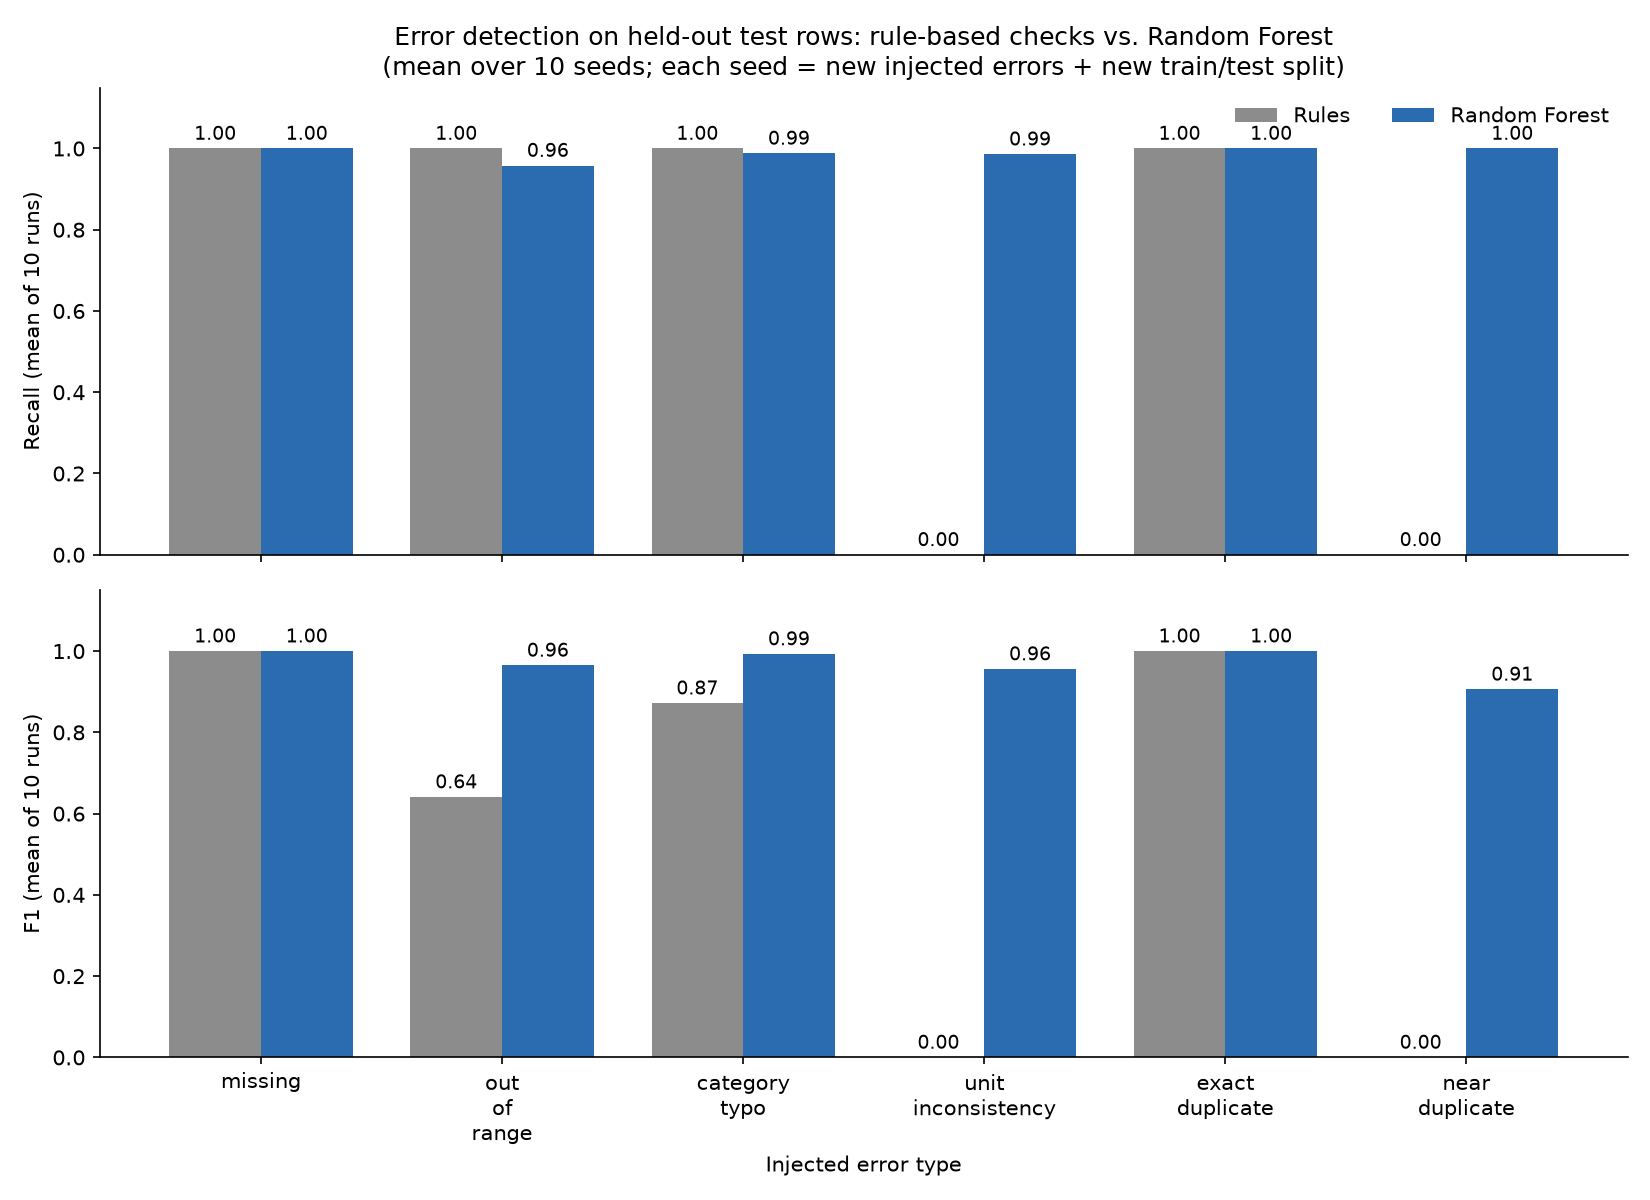

In [13]:
display(Image(filename=str(RESULTS_DIR / "detection_comparison.png")))

## 7. Findings, limitations, next steps

**Findings** (exact numbers in the tables above and in the README)
- **Rules are perfect where the error is well-defined**: missing values and exact duplicates are caught with precision and recall of 1.0. No ML is needed there.
- **Rules detect but mislabel unit errors**: every unit error falls outside a plausible range, so the rules *flag* it (`recall_any` = 1.0) but call it `out_of_range`. The Random Forest learns the tell-tale ratio to the median and names the error correctly, which matters because the *fix* is different (convert the unit vs. delete the value).
- **Near-duplicates are the rules' blind spot**: rules find none of them. The Random Forest, using a "distance to the most similar earlier record" feature (a mini entity-resolution step), finds them, with some false alarms.
- **Isolation Forest (no labels)** ranks dirty rows above clean ones better than chance (ROC-AUC well above 0.5), but with a 10% review budget it catches only a small share of the dirty rows and never flags exact duplicates: a duplicate looks perfectly *normal*.

**Limitations**
- Errors are synthetic; real errors are messier and correlated (one bad device, one careless clerk).
- Small dataset (297 patients), so each test split has only a handful of errors per type.
- The Random Forest is supervised and trained on the same error generator it is tested on - an optimistic setting. Isolation Forest needs no labels, which is the realistic setting.
- Plausible ranges and some features (e.g. distance outside the range) are hand-chosen; the Random Forest partly *reuses* rule knowledge.

**Next steps**
- Extend near-duplicate detection into proper entity resolution (blocking + pairwise matching) and plug the ML quality scorer into a Data Washing Machine-style pipeline.
- Reduce the need for labels: weak supervision (rules as noisy labels), active learning, or semi-supervised anomaly detection.
- Test on real clinical data with real errors, e.g. MIMIC.